In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 89.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e8ed6370159635897e90203a12767ffce3d166d8ae526f8c3fd847e9701e2dd1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


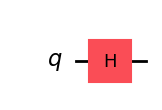

In [2]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [3]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [4]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [5]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [6]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

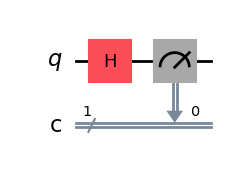

In [7]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [8]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [9]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 505, '1': 519}


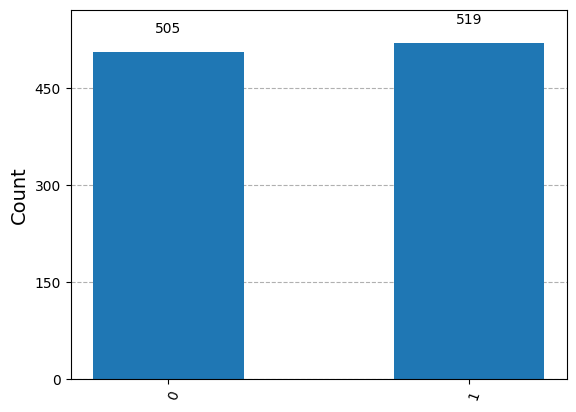

In [10]:
# We can also produce a graph

plot_histogram(counts)

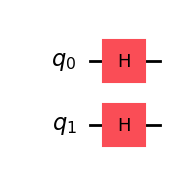

In [11]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [12]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

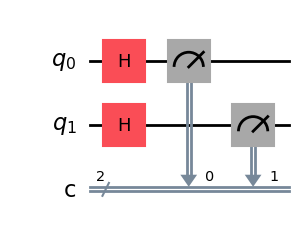

In [13]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

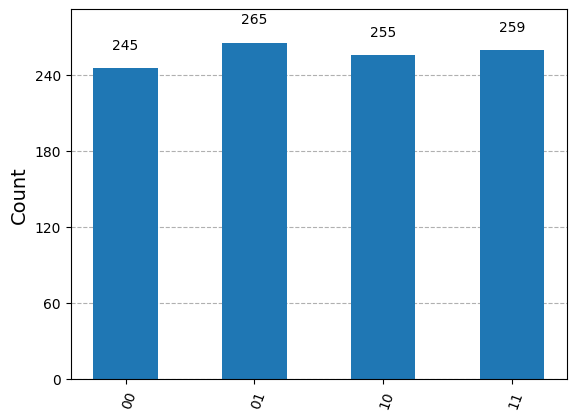

In [14]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

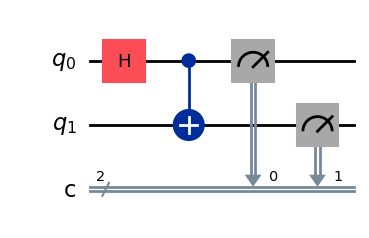

In [15]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

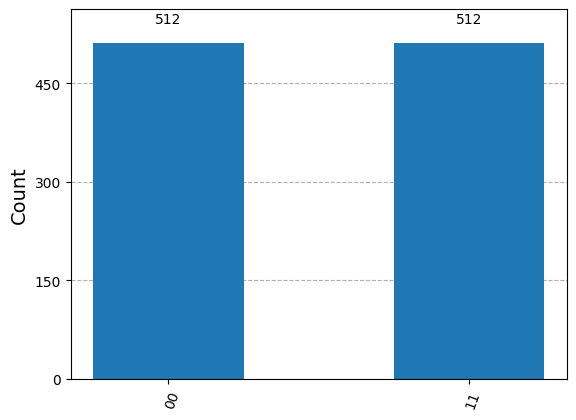

In [16]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [21]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

Phi+


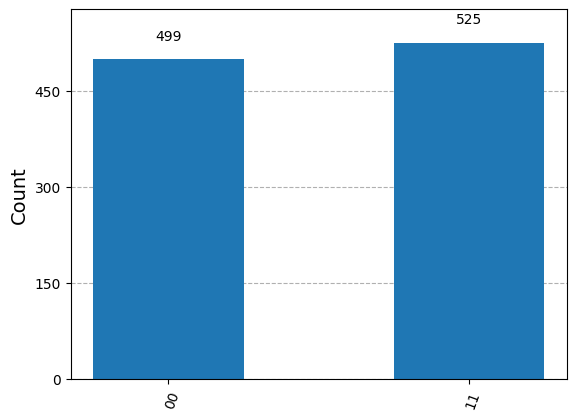

Phi-


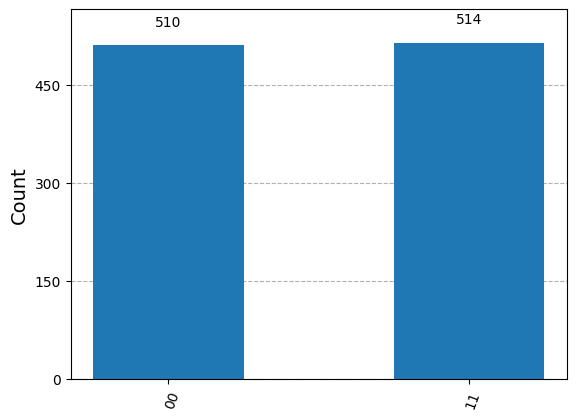

Psi+


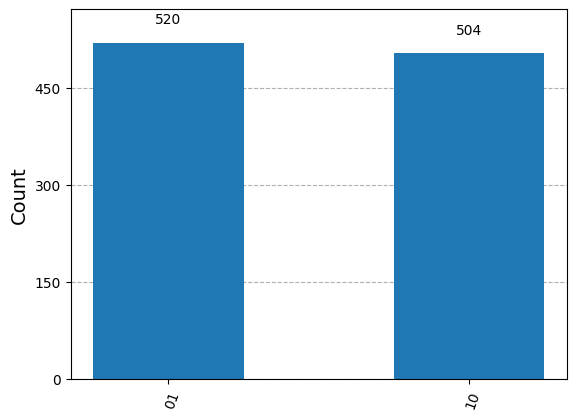

Psi-


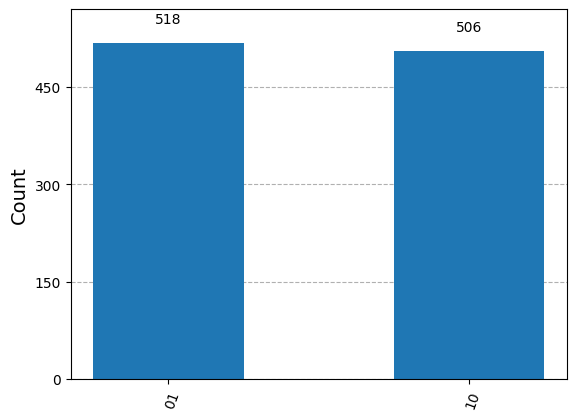

In [26]:
# EXERCISE - Bell States
# Using exactly the same patterns as the worksheet

# ── Φ+ = (1/√2)(|00> + |11>) — base Bell state ──────────────────────────────
circuit1 = QuantumCircuit(2)
circuit1.h(0)
circuit1.cx(0, 1)
circuit1.draw("mpl")

state = Statevector.from_int(0, 4)
state = state.evolve(circuit1)
state.draw("latex")

# ── Φ- = (1/√2)(|00> - |11>) — apply Z to qubit 0 after base circuit ────────
circuit2 = QuantumCircuit(2)
circuit2.h(0)
circuit2.cx(0, 1)
circuit2.z(0)   # Z flips the sign of |1>, making the |11> term negative
circuit2.draw("mpl")

state = Statevector.from_int(0, 4)
state = state.evolve(circuit2)
state.draw("latex")

# ── Ψ+ = (1/√2)(|01> + |10>) — apply X to qubit 1 after base circuit ────────
circuit3 = QuantumCircuit(2)
circuit3.h(0)
circuit3.cx(0, 1)
circuit3.x(1)   # X flips second qubit: |00>→|01>, |11>→|10>
circuit3.draw("mpl")

state = Statevector.from_int(0, 4)
state = state.evolve(circuit3)
state.draw("latex")

# ── Ψ- = (1/√2)(|01> - |10>) — apply X to qubit 1 AND Z to qubit 0 ──────────
circuit4 = QuantumCircuit(2)
circuit4.h(0)
circuit4.cx(0, 1)
circuit4.x(1)   # flip second qubit
circuit4.z(0)   # add minus sign
circuit4.draw("mpl")

state = Statevector.from_int(0, 4)
state = state.evolve(circuit4)
state.draw("latex")

# ── Measurements for all four Bell states ────────────────────────────────────
# Using the same compose pattern from the worksheet

def measure_bell(circuit, label):
    meas = QuantumCircuit(2, 2)
    meas.measure(range(2), range(2))
    qc = meas.compose(circuit, range(2), front=True)

    qc_compiled = transpile(qc, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)

    print(label)
    return plot_histogram(counts)

# measure_bell(circuit1, "Φ+  (|00> + |11>)")

# measure_bell(circuit2, "Φ-  (|00> - |11>)")

# measure_bell(circuit3, "Ψ+  (|01> + |10>)")

# measure_bell(circuit4, "Ψ-  (|01> - |10>)")
from IPython.display import display
display(measure_bell(circuit1, "Phi+"))
display(measure_bell(circuit2, "Phi-"))
display(measure_bell(circuit3, "Psi+"))
display(measure_bell(circuit4, "Psi-"))

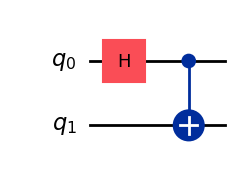

<IPython.core.display.Latex object>

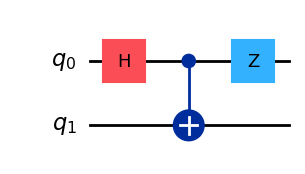

<IPython.core.display.Latex object>

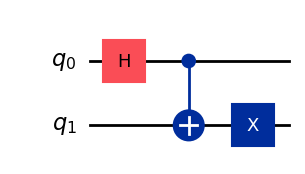

<IPython.core.display.Latex object>

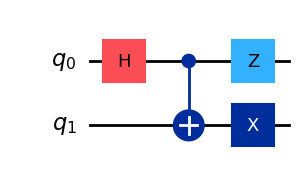

<IPython.core.display.Latex object>

Phi+  (|00> + |11>)


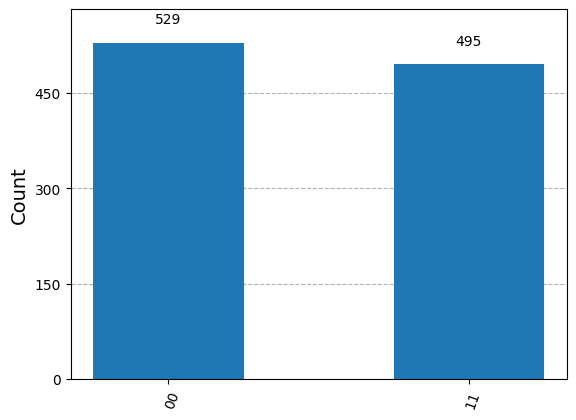

Phi-  (|00> - |11>)


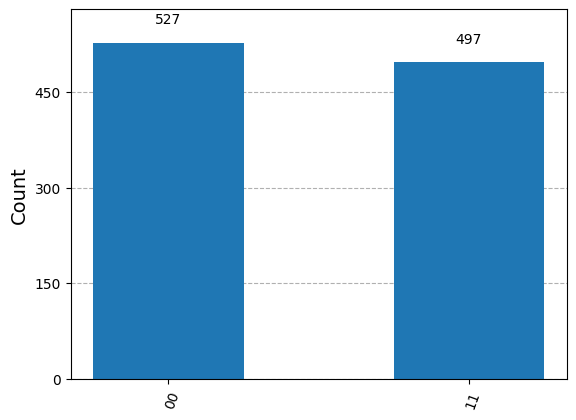

Psi+  (|01> + |10>)


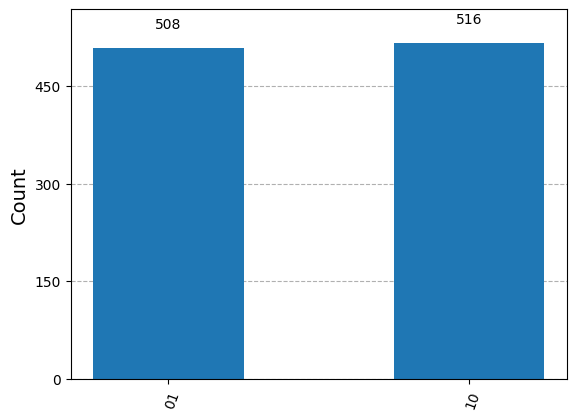

Psi-  (|01> - |10>)


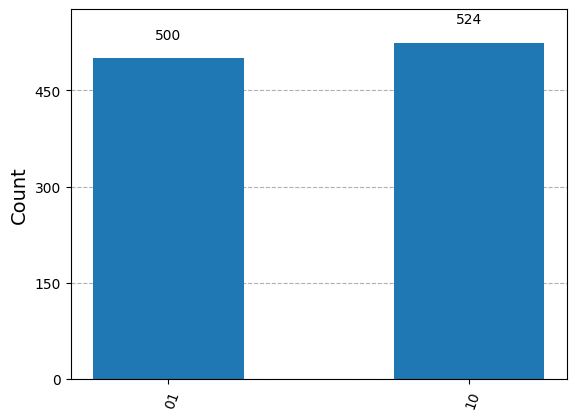

In [27]:
from IPython.display import display

# ── Φ+ = (1/√2)(|00> + |11>) ─────────────────────────────────────────────────
circuit1 = QuantumCircuit(2)
circuit1.h(0)
circuit1.cx(0, 1)
display(circuit1.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit1)
display(state.draw("latex"))

# ── Φ- = (1/√2)(|00> - |11>) ─────────────────────────────────────────────────
circuit2 = QuantumCircuit(2)
circuit2.h(0)
circuit2.cx(0, 1)
circuit2.z(0)
display(circuit2.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit2)
display(state.draw("latex"))

# ── Ψ+ = (1/√2)(|01> + |10>) ─────────────────────────────────────────────────
circuit3 = QuantumCircuit(2)
circuit3.h(0)
circuit3.cx(0, 1)
circuit3.x(1)
display(circuit3.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit3)
display(state.draw("latex"))

# ── Ψ- = (1/√2)(|01> - |10>) ─────────────────────────────────────────────────
circuit4 = QuantumCircuit(2)
circuit4.h(0)
circuit4.cx(0, 1)
circuit4.x(1)
circuit4.z(0)
display(circuit4.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit4)
display(state.draw("latex"))

# ── Measurements ──────────────────────────────────────────────────────────────
def measure_bell(circuit, label):
    meas = QuantumCircuit(2, 2)
    meas.measure(range(2), range(2))
    qc = meas.compose(circuit, range(2), front=True)
    qc_compiled = transpile(qc, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)
    print(label)
    return plot_histogram(counts)

display(measure_bell(circuit1, "Phi+  (|00> + |11>)"))
display(measure_bell(circuit2, "Phi-  (|00> - |11>)"))
display(measure_bell(circuit3, "Psi+  (|01> + |10>)"))
display(measure_bell(circuit4, "Psi-  (|01> - |10>)"))

In [18]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?


2-qubit GHZ circuit:


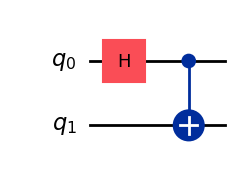

<IPython.core.display.Latex object>


3-qubit GHZ circuit:


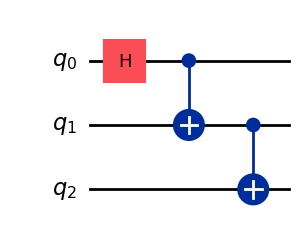

<IPython.core.display.Latex object>


4-qubit GHZ circuit:


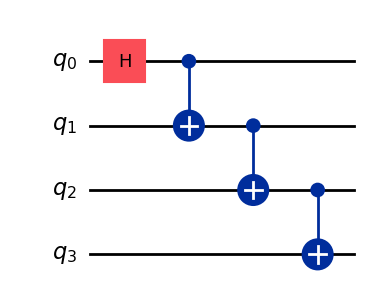

<IPython.core.display.Latex object>

n=2 qubits — time: 0.01s — results: {'00': 479, '11': 545}


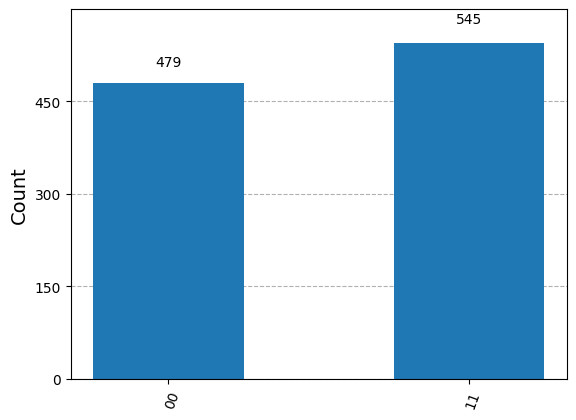

n=3 qubits — time: 0.01s — results: {'111': 537, '000': 487}


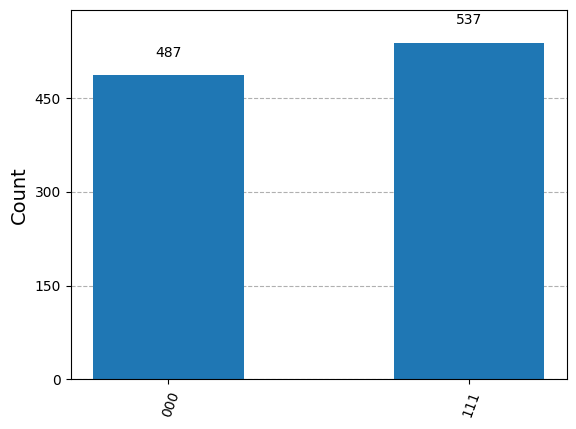

n=4 qubits — time: 0.01s — results: {'1111': 530, '0000': 494}


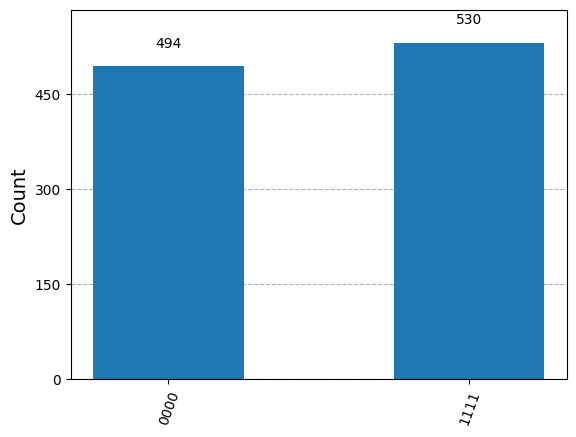

n=5 qubits — time: 0.01s — results: {'11111': 514, '00000': 510}


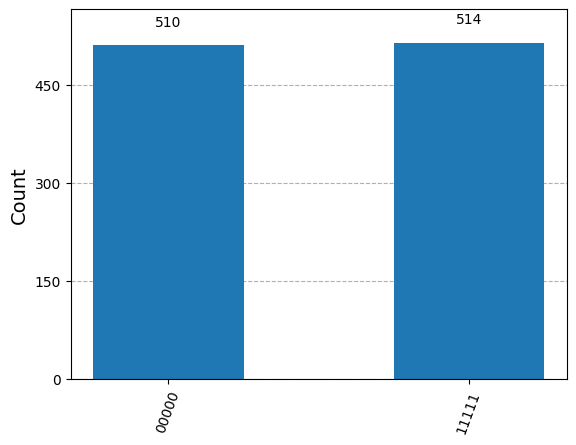

n=10 qubits — time: 0.03s — results: {'1111111111': 515, '0000000000': 509}


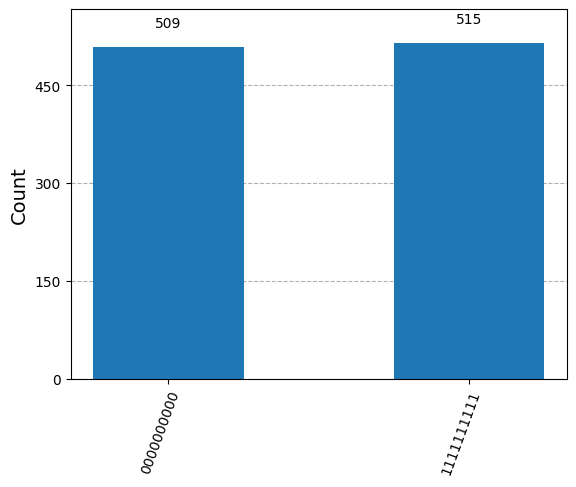

n=15 qubits — time: 0.09s — results: {'000000000000000': 516, '111111111111111': 508}


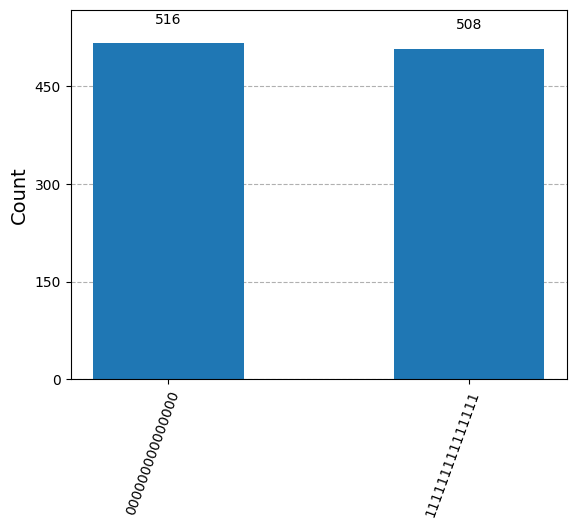

n=20 qubits — time: 1.03s — results: {'11111111111111111111': 509, '00000000000000000000': 515}


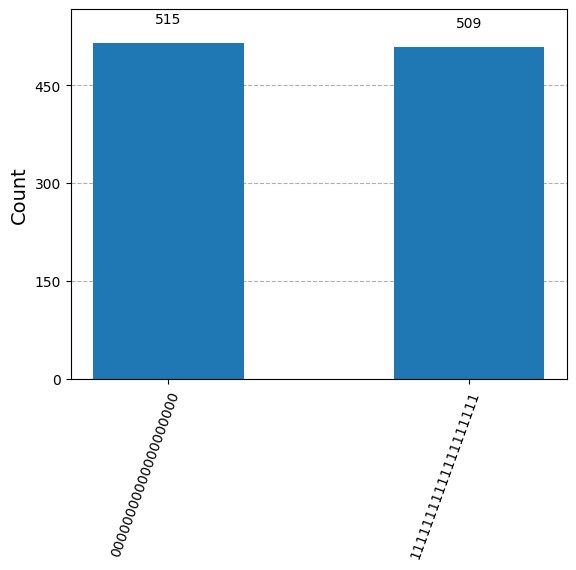

In [29]:
from IPython.display import display
import time

# ── GHZ circuit for any number of qubits ─────────────────────────────────────
def make_ghz(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(0)                            # superposition on first qubit
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)                # chain of CNOTs to spread entanglement
    return qc

# ── Show circuit and state vector for 2, 3 and 4 qubits ──────────────────────
for n in [2, 3, 4]:
    qc = make_ghz(n)
    print(f"\n{n}-qubit GHZ circuit:")
    display(qc.draw("mpl"))
    state = Statevector.from_int(0, 2**n)
    state = state.evolve(qc)
    display(state.draw("latex"))

# ── Measurements: find how many qubits the simulator can handle ───────────────
def measure_ghz(n):
    qc = make_ghz(n)
    meas = QuantumCircuit(n, n)
    meas.measure(range(n), range(n))
    qc_m = meas.compose(qc, range(n), front=True)

    qc_compiled = transpile(qc_m, backend)
    start = time.time()
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    elapsed = time.time() - start

    counts = result_sim.get_counts(qc_compiled)
    print(f"n={n} qubits — time: {elapsed:.2f}s — results: {counts}")
    display(plot_histogram(counts))

# Try increasing qubit counts to find the practical limit
for n in [2, 3, 4, 5, 10, 15, 20]:
    measure_ghz(n)

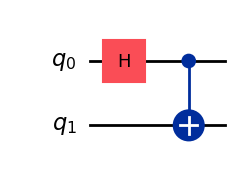

<IPython.core.display.Latex object>

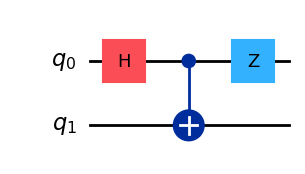

<IPython.core.display.Latex object>

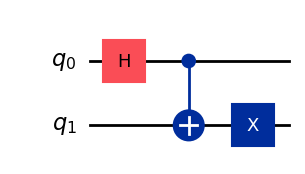

<IPython.core.display.Latex object>

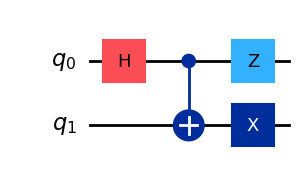

<IPython.core.display.Latex object>

Phi+  (|00> + |11>)


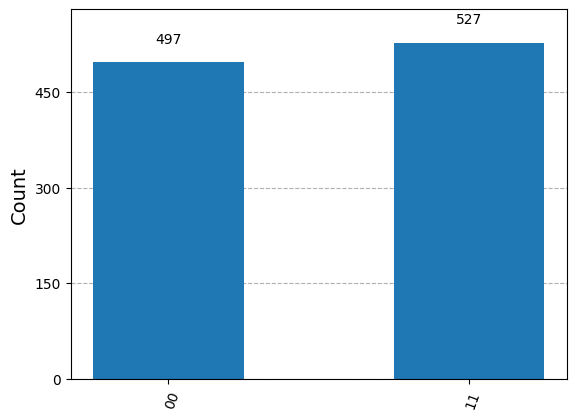

Phi-  (|00> - |11>)


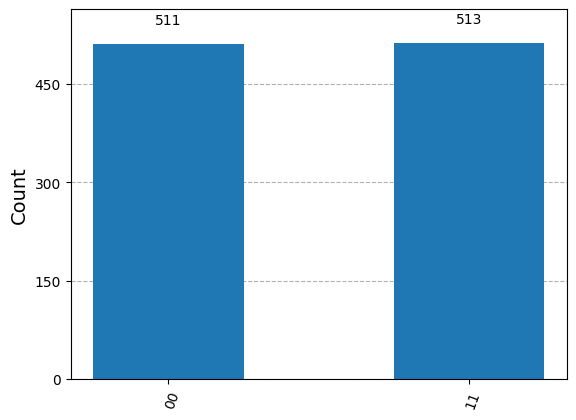

Psi+  (|01> + |10>)


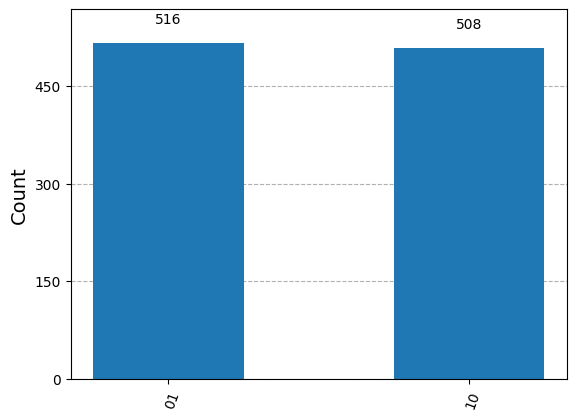

Psi-  (|01> - |10>)


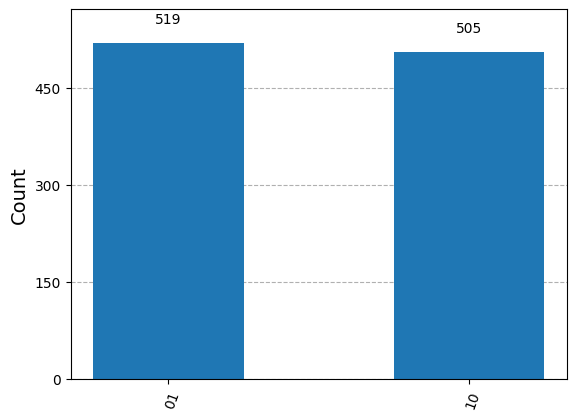

In [30]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

from IPython.display import display

# Phi+ = 1/sqrt(2) ( |00> + |11> ) -- base Bell state
circuit1 = QuantumCircuit(2)
circuit1.h(0)
circuit1.cx(0, 1)
display(circuit1.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit1)
display(state.draw("latex"))

# Phi- = 1/sqrt(2) ( |00> - |11> ) -- add Z on qubit 0
circuit2 = QuantumCircuit(2)
circuit2.h(0)
circuit2.cx(0, 1)
circuit2.z(0)
display(circuit2.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit2)
display(state.draw("latex"))

# Psi+ = 1/sqrt(2) ( |01> + |10> ) -- add X on qubit 1
circuit3 = QuantumCircuit(2)
circuit3.h(0)
circuit3.cx(0, 1)
circuit3.x(1)
display(circuit3.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit3)
display(state.draw("latex"))

# Psi- = 1/sqrt(2) ( |01> - |10> ) -- add X on qubit 1 and Z on qubit 0
circuit4 = QuantumCircuit(2)
circuit4.h(0)
circuit4.cx(0, 1)
circuit4.x(1)
circuit4.z(0)
display(circuit4.draw("mpl"))

state = Statevector.from_int(0, 4)
state = state.evolve(circuit4)
display(state.draw("latex"))

# Measurements for all four Bell states
def measure_bell(circuit, label):
    meas = QuantumCircuit(2, 2)
    meas.measure(range(2), range(2))
    qc = meas.compose(circuit, range(2), front=True)
    qc_compiled = transpile(qc, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)
    print(label)
    return plot_histogram(counts)

display(measure_bell(circuit1, "Phi+  (|00> + |11>)"))
display(measure_bell(circuit2, "Phi-  (|00> - |11>)"))
display(measure_bell(circuit3, "Psi+  (|01> + |10>)"))
display(measure_bell(circuit4, "Psi-  (|01> - |10>)"))


2-qubit GHZ circuit:


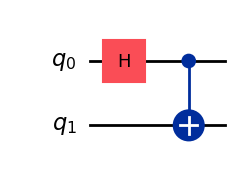

<IPython.core.display.Latex object>


3-qubit GHZ circuit:


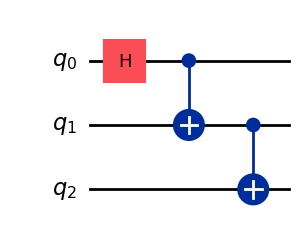

<IPython.core.display.Latex object>


4-qubit GHZ circuit:


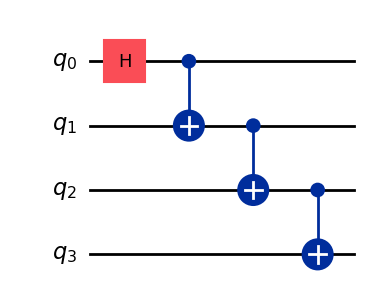

<IPython.core.display.Latex object>


5-qubit GHZ circuit:


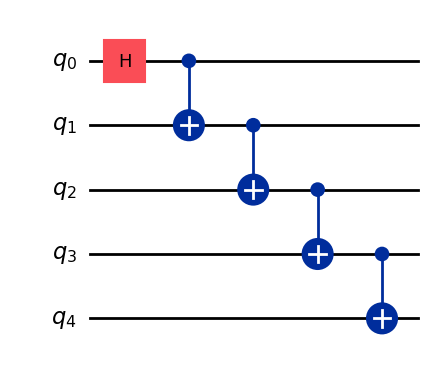

<IPython.core.display.Latex object>


6-qubit GHZ circuit:


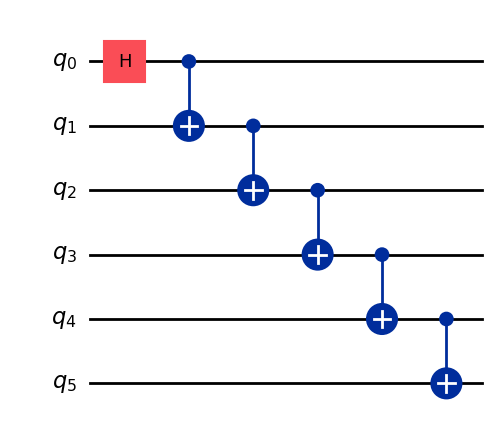

<IPython.core.display.Latex object>


7-qubit GHZ circuit:


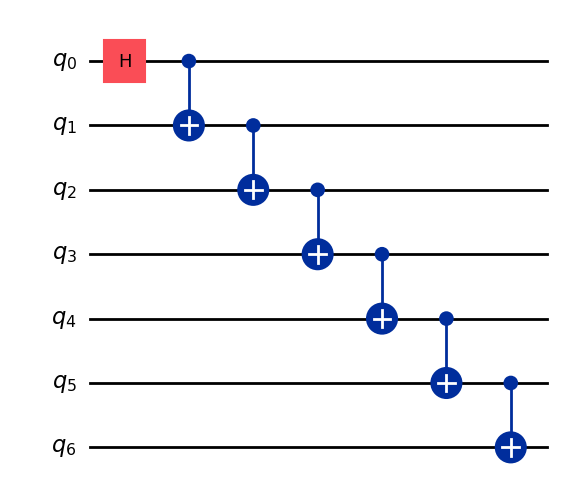

<IPython.core.display.Latex object>

n=2 qubits -- time: 0.01s -- results: {'00': 501, '11': 523}


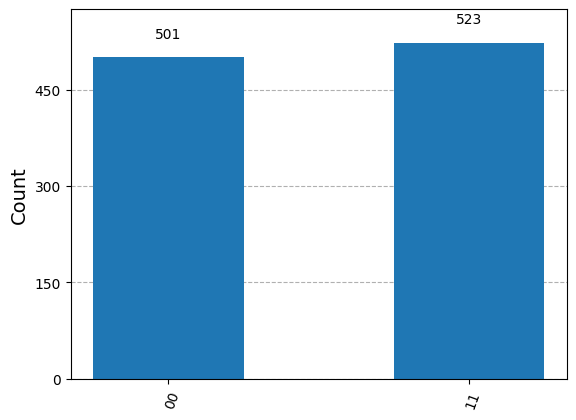

n=3 qubits -- time: 0.01s -- results: {'000': 524, '111': 500}


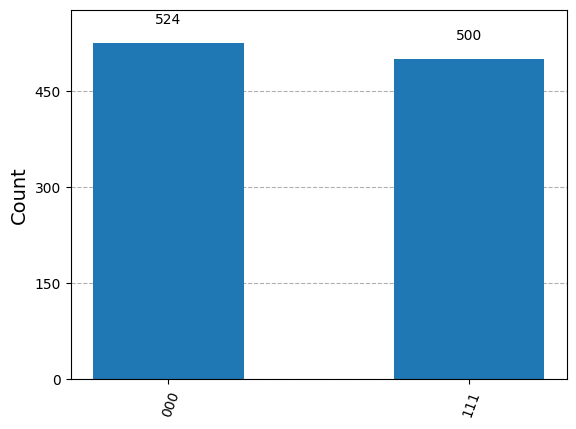

n=4 qubits -- time: 0.01s -- results: {'0000': 540, '1111': 484}


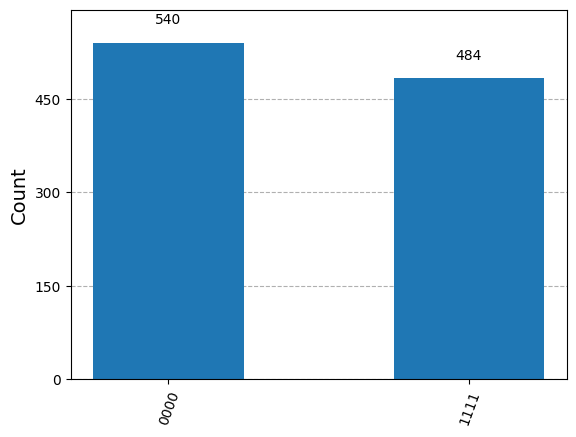

n=5 qubits -- time: 0.00s -- results: {'00000': 500, '11111': 524}


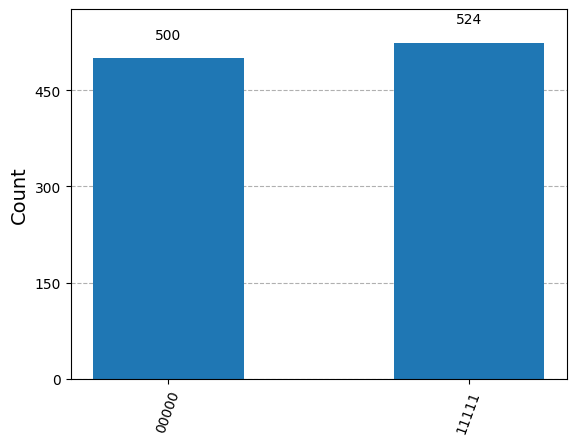

n=10 qubits -- time: 0.01s -- results: {'0000000000': 535, '1111111111': 489}


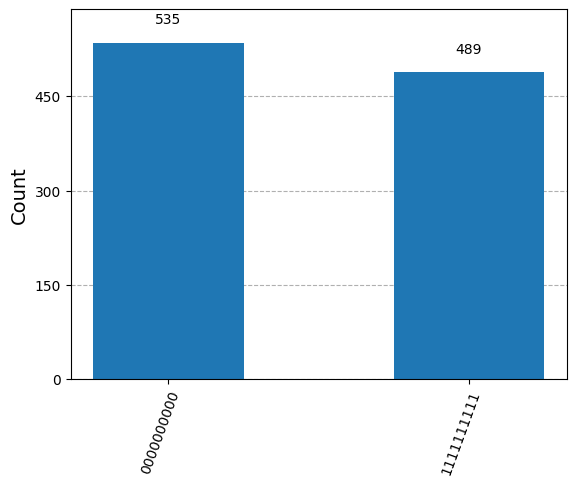

n=15 qubits -- time: 0.03s -- results: {'000000000000000': 495, '111111111111111': 529}


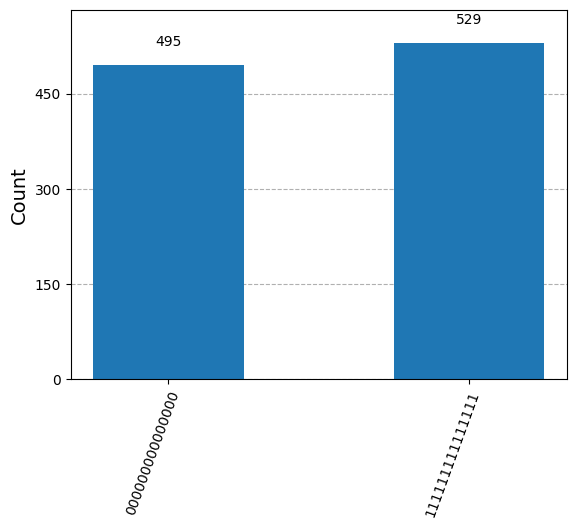

n=20 qubits -- time: 0.79s -- results: {'11111111111111111111': 497, '00000000000000000000': 527}


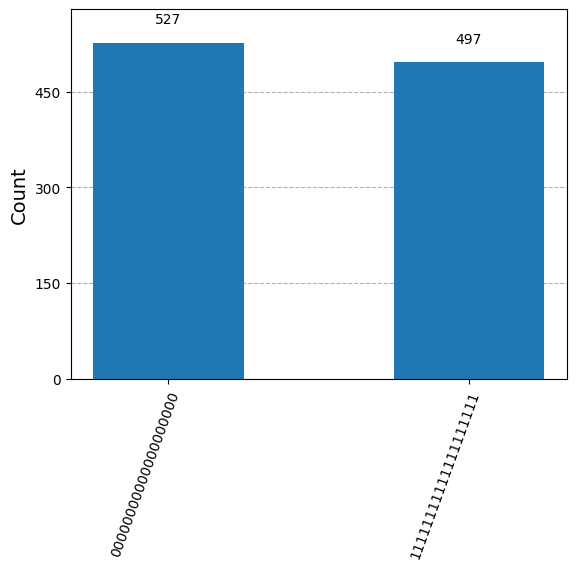

In [32]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

import time
from IPython.display import display

def make_ghz(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(0)
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
    return qc

# Show circuit and state vector for 2, 3 and 4 qubits
for n in [2, 3, 4, 5, 6, 7]:
    qc = make_ghz(n)
    print(f"\n{n}-qubit GHZ circuit:")
    display(qc.draw("mpl"))
    state = Statevector.from_int(0, 2**n)
    state = state.evolve(qc)
    display(state.draw("latex"))

# Simulate with measurements for increasing qubit counts
def measure_ghz(n):
    qc = make_ghz(n)
    meas = QuantumCircuit(n, n)
    meas.measure(range(n), range(n))
    qc_m = meas.compose(qc, range(n), front=True)
    qc_compiled = transpile(qc_m, backend)
    start = time.time()
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    elapsed = time.time() - start
    counts = result_sim.get_counts(qc_compiled)
    print(f"n={n} qubits -- time: {elapsed:.2f}s -- results: {counts}")
    display(plot_histogram(counts))

for n in [2, 3, 4, 5, 10, 15, 20]:
    measure_ghz(n)